<a href="https://colab.research.google.com/github/swhoyle/electric-load-forecasting/blob/main/Electric_Load_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Electric Load Forecasting

Spencer Hoyle  
UCSD DSE 260 - Spring 2026

Objective
---
Build a model to predict and forecast electric load.

We want to predict both short term (next minute to hour) and longer term (next day - 24 hours).

Dataset
---
A commercial business (Bakery) in Europe has provided 1-second power load data in Watts (W) recorded by electric meters in the business facilities.

- **Date range:**  11/28/2025 → 4/8/2026
- **Total days:**  132  
- **Shape:**      (11404800, 2)  

Each day has a work day classification label, provided by the customer:
- `full`: Full working day (both facility and bakery are open)
- `half`: Half working day (only facility is open; bakery is closed)
- `none`: Not a working day (both facility and bakery are closed)




## Imports

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
import xgboost as xgb

from scipy.io import loadmat
from matplotlib.patches import Patch
from sklearn.metrics import mean_absolute_error
from IPython.display import display
from google.colab import drive

plt.style.use("default")
color_palette = sns.color_palette()
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Data

Load raw data

In [119]:
raw_data = loadmat("/content/drive/MyDrive/ElectricLoadForecast/P_data.mat")
raw_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Apr 13 17:06:08 2026',
 '__version__': '1.0',
 '__globals__': [],
 'P_data': array([[1925., 1301., 1320., ..., 1380., 1400., 1280.],
        [1922., 1296., 1320., ..., 1388., 1400., 1264.],
        [1921., 1285., 1316., ..., 1386., 1398., 1267.],
        ...,
        [1253., 1315., 1518., ..., 1399., 1275., 2380.],
        [1248., 1315., 1506., ..., 1399., 1280., 2383.],
        [1249., 1317., 1516., ..., 1401., 1274., 2384.]]),
 'day_data': array([[array(['2025/11/28'], dtype='<U10'),
         array(['2025/11/29'], dtype='<U10'),
         array(['2025/11/30'], dtype='<U10'),
         array(['2025/12/01'], dtype='<U10'),
         array(['2025/12/02'], dtype='<U10'),
         array(['2025/12/03'], dtype='<U10'),
         array(['2025/12/04'], dtype='<U10'),
         array(['2025/12/05'], dtype='<U10'),
         array(['2025/12/06'], dtype='<U10'),
         array(['2025/12/07'], dtype='<U10'),
         array(['2025/12

In [120]:
raw_data["P_data"][0]

array([1925., 1301., 1320., 1496., 2568., 2574., 1629., 1852., 1549.,
       4226., 1624., 3286., 1645., 1289., 1442., 2285., 2357., 1055.,
       2255., 2043., 1318., 1735., 1455., 1812., 1151., 1137., 3991.,
       2403., 2123., 2606., 1318., 1462., 1861., 1776., 1746., 1780.,
       1167., 2516., 1635., 3744., 4473., 1949., 1763., 1793., 1601.,
       2445., 2243.,  656.,  723.,  441., 1860., 5409., 2286., 1423.,
       2272., 1196., 2433., 1478., 1839., 4977., 2227., 2516., 2033.,
       1769., 1524., 6609., 1904., 2150., 3681., 2711., 2106., 1686.,
        950., 1471., 2047., 1042., 6290., 1667., 1575., 5832., 1904.,
       1655., 2250., 3531., 3126.,  820.,  698., 1449., 2807.,  501.,
       1667., 3465., 1090.,  759.,  653.,  507.,  692., 1083., 5432.,
       1825., 1035., 1051., 2284., 1268., 8466., 1066., 1877., 2005.,
        922., 1974., 3319.,  645., 1187., 1258., 6033., 5225.,  423.,
       1223., 2551., 1900., 2276., 2838., 2556., 1953., 2394., 1541.,
       2265., 1095.,

In [121]:
p_data = raw_data["P_data"]
day_data = raw_data["day_data"]
day_class = raw_data["day_class"]

print("p_data shape:   ", p_data.shape)
print("day_data shape: ", day_data.shape)
print("day_class shape:", day_class.shape)

p_data shape:    (86400, 132)
day_data shape:  (1, 132)
day_class shape: (1, 132)


In [122]:
p_data

array([[1925., 1301., 1320., ..., 1380., 1400., 1280.],
       [1922., 1296., 1320., ..., 1388., 1400., 1264.],
       [1921., 1285., 1316., ..., 1386., 1398., 1267.],
       ...,
       [1253., 1315., 1518., ..., 1399., 1275., 2380.],
       [1248., 1315., 1506., ..., 1399., 1280., 2383.],
       [1249., 1317., 1516., ..., 1401., 1274., 2384.]])

Restructure raw data into data frame

In [123]:
columns = pd.to_datetime([d[0] for d in day_data.squeeze()])

df = (
    pd.DataFrame(p_data, columns=columns)
    .assign(second_of_day=np.arange(86400))
    .melt(id_vars="second_of_day", var_name="date", value_name="load")
    .assign(
        date=lambda x: pd.to_datetime(x["date"]),
        timestamp=lambda x: x["date"] + pd.to_timedelta(x["second_of_day"], unit="s")
    )
    .sort_values("timestamp")
    .reset_index(drop=True)
)

day_class_df = pd.DataFrame({
    "date": columns,
    "day_class": [d[0] for d in day_class.squeeze()]
})

df = df.merge(
    day_class_df,
    left_on=pd.to_datetime(df["timestamp"].dt.date),
    right_on="date",
    how="left"
)

df = df[["timestamp", "load", "day_class"]].set_index("timestamp")

print(df.shape)
df.head()

(11404800, 2)


,load,day_class
timestamp,,
2025-11-28 00:00:00,1925.0,full
2025-11-28 00:00:01,1922.0,full
2025-11-28 00:00:02,1921.0,full
2025-11-28 00:00:03,1921.0,full
2025-11-28 00:00:04,1926.0,full


## Exploratory Data Analysis

In [124]:
raw_df = df.copy()

In [125]:
print("Raw Data")
print("-------------------------")
print(f"Date range:  {raw_df.index.min()}  →  {raw_df.index.max()}")
print(f"Total days:  {raw_df.index.normalize().nunique()}")
print(f"Shape:       {raw_df.shape}")
print("-------------------------")
raw_df.head()

Raw Data
-------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:59:59
Total days:  132
Shape:       (11404800, 2)
-------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1925.0,full
2025-11-28 00:00:01,1922.0,full
2025-11-28 00:00:02,1921.0,full
2025-11-28 00:00:03,1921.0,full
2025-11-28 00:00:04,1926.0,full


### Downsample to 1 minute resolution

In [126]:
df = raw_df.resample('1min').agg({'load': 'mean', 'day_class': 'first'})

print("Resampled Data (1 min)")
print("-------------------------")
print(f"Date range:  {df.index.min()}  →  {df.index.max()}")
print(f"Total days:  {df.index.normalize().nunique()}")
print(f"Shape:       {df.shape}")
print("-------------------------")
df.head()

Resampled Data (1 min)
-------------------------
Date range:  2025-11-28 00:00:00  →  2026-04-08 23:59:00
Total days:  132
Shape:       (190080, 2)
-------------------------


,load,day_class
timestamp,,
2025-11-28 00:00:00,1912.400000,full
2025-11-28 00:01:00,1908.233333,full
2025-11-28 00:02:00,1643.183333,full
2025-11-28 00:03:00,2992.950000,full
2025-11-28 00:04:00,1106.000000,full


### Missing Values

In [127]:
print(f"Missing values (raw 1-second resolution):")
print("-------------------------")
total = len(raw_df)
missing = raw_df.isnull().sum()
pct = ((missing / total) * 100).round(2)
print(pd.DataFrame({'missing': missing, '%': pct}))
print("-------------------------")

print(f"\nMissing values (1-minute resolution):")
print("-------------------------")
total = len(df)
missing = df.isnull().sum()
pct = ((missing / total) * 100).round(2)
print(pd.DataFrame({'missing': missing, '%': pct}))
print("-------------------------")

Missing values (raw 1-second resolution):
-------------------------
           missing    %
load         46099  0.4
day_class        0  0.0
-------------------------

Missing values (1-minute resolution):
-------------------------
           missing     %
load            74  0.04
day_class        0  0.00
-------------------------


### Zero Load

In [154]:
print("Zero Load Values (raw 1-second resolution):")
print("-------------------------")
total = len(raw_df)
zero = raw_df[raw_df['load'] == 0].shape[0]
pct = round((zero / total) * 100, 2)
print(pd.DataFrame({'count': [zero], '%': [pct]}))
print("-------------------------")

print("\nZero Load Values (1-minute resolution):")
print("-------------------------")
total = len(df)
zero = df[df['load']  == 0].shape[0]
pct = round((zero / total) * 100, 2)
print(pd.DataFrame({'count': [zero], '%': [pct]}))
print("-------------------------")

Zero Load Values (raw 1-second resolution):
-------------------------
   count    %
0    261  0.0
-------------------------

Zero Load Values (1-minute resolution):
-------------------------
   count    %
0      0  0.0
-------------------------


### Negative Load

In [129]:
print("Negative Load Values (raw 1-second resolution):")
print("-------------------------")
total = len(raw_df)
negative = raw_df[raw_df['load'] < 0].shape[0]
pct = round((negative / total) * 100, 2)
print(pd.DataFrame({'count': [negative], '%': [pct]}))
print("-------------------------")

print("\nNegative Load Values (1-minute resolution):")
print("-------------------------")
total = len(df)
negative = df[df['load'] < 0].shape[0]
pct = round((negative / total) * 100, 2)
print(pd.DataFrame({'count': [negative], '%': [pct]}))
print("-------------------------")

Negative Load Values (raw 1-second resolution):
-------------------------
    count     %
0  703079  6.16
-------------------------

Negative Load Values (1-minute resolution):
-------------------------
   count     %
0  11340  5.97
-------------------------


### Full time-series Plot

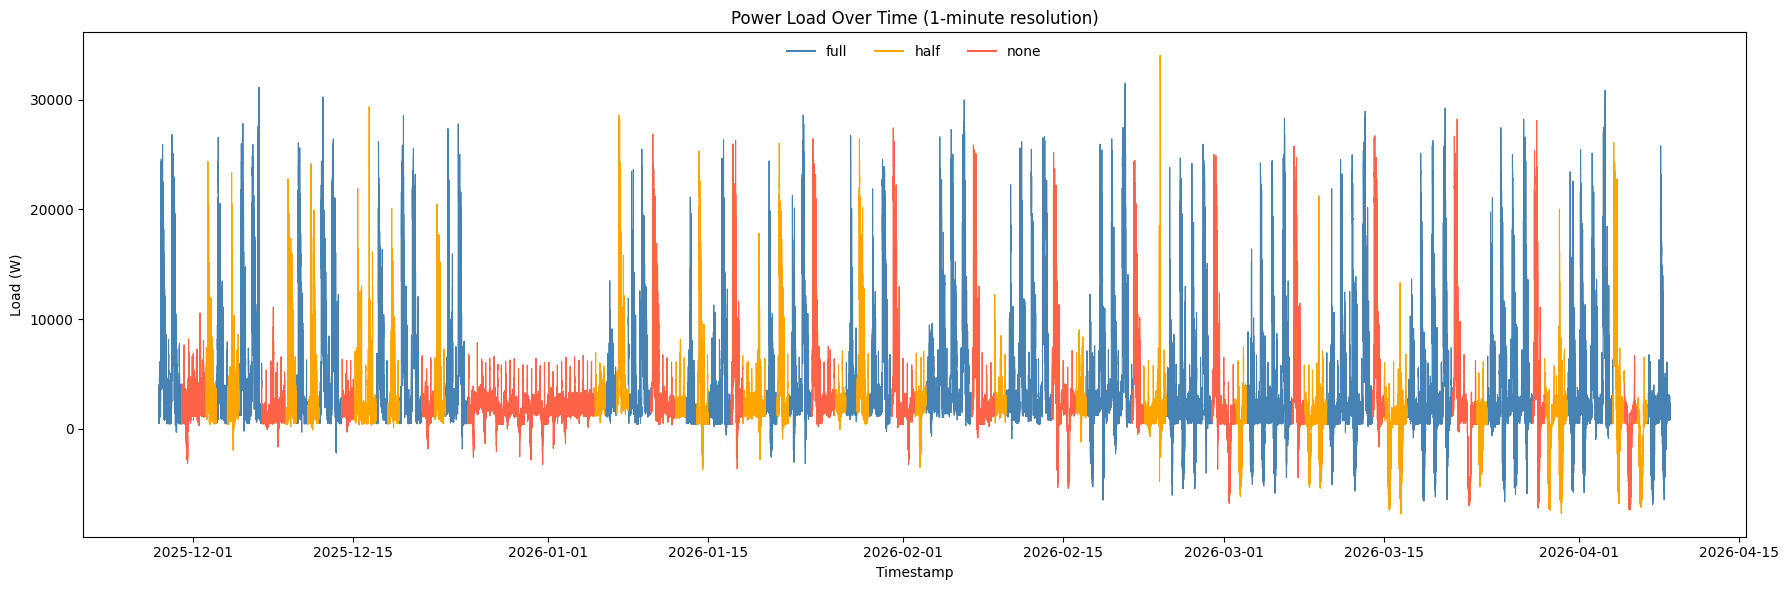

In [130]:
color_map = {'full': 'steelblue', 'half': 'orange', 'none': 'tomato'}

plt.figure(figsize=(18, 6))
for cls in color_map:
    masked = df['load'].copy()
    masked[df['day_class'] != cls] = np.nan
    plt.plot(masked.index, masked, color=color_map[cls], linewidth=0.8, label=cls)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=color_map[cls], label=cls) for cls in color_map]
plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.title("Power Load Over Time (1-minute resolution)")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

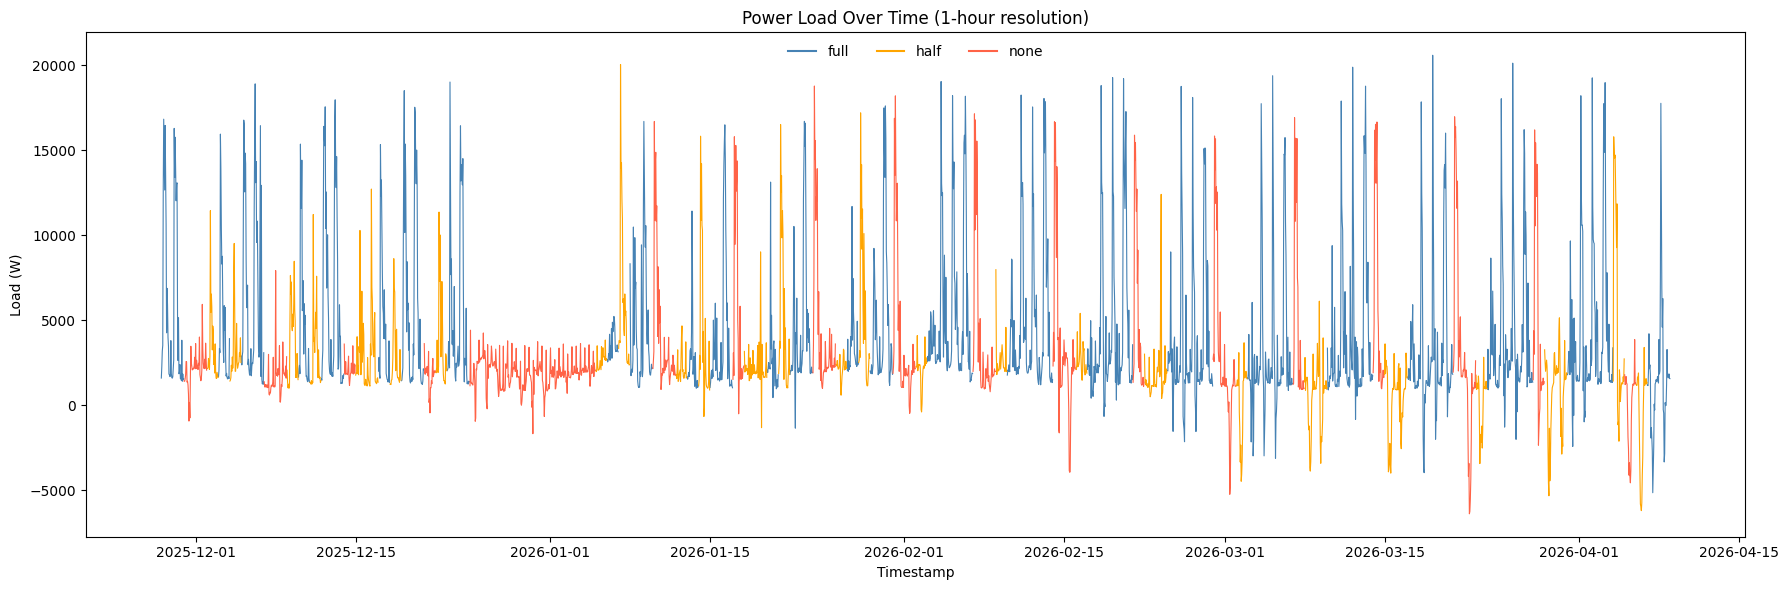

In [131]:
color_map = {'full': 'steelblue', 'half': 'orange', 'none': 'tomato'}

df_1h = df.resample('1h').agg({'load': 'mean', 'day_class': 'first'})

plt.figure(figsize=(18, 6))
for cls in color_map:
    masked = df_1h['load'].copy()
    masked[df_1h['day_class'] != cls] = np.nan
    plt.plot(masked.index, masked, color=color_map[cls], linewidth=0.8, label=cls)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=color_map[cls], label=cls) for cls in color_map]
plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.title("Power Load Over Time (1-hour resolution)")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

### Single-Day Load Plot

In [ ]:
dates = df.index.normalize().unique().sort_values()
daily_summary = df.groupby(df.index.normalize()).agg(
    day_class=('day_class', 'first'),
    avg_load=('load', 'mean')
)

options = [
    f"{d.strftime('%Y-%m-%d')} ({daily_summary.loc[d, 'day_class']}) ({daily_summary.loc[d, 'avg_load']:.0f}W avg)"
    for d in dates
]

dropdown = widgets.Dropdown(options=options, description='Date:')

def plot_day(option):
    date = option.split(' ')[0]
    cls = option.split('(')[1].rstrip(') ')
    data = df.loc[date]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(data.index, data['load'], color=color_map[cls], linewidth=0.8)
    ax.set_title(f"Power Load — {option}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Load (W)")
    plt.tight_layout()
    plt.show()

widgets.interact(plot_day, option=dropdown)

### Load Distribution

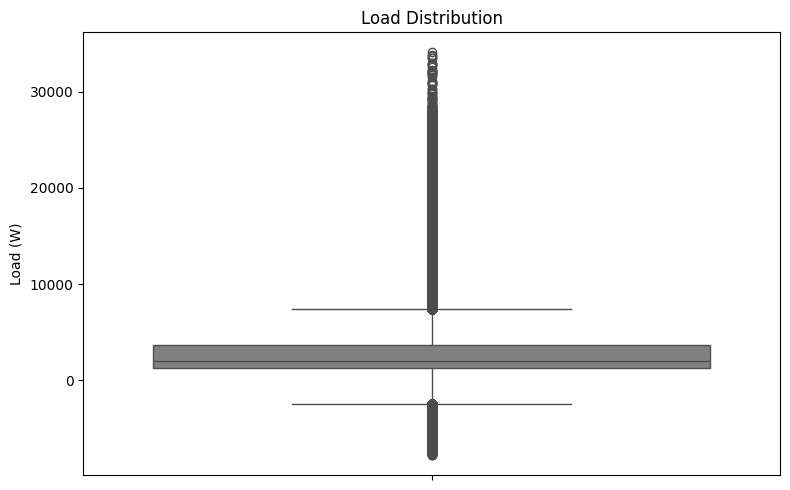

Load Stats:


,count,mean,std,min,25%,50%,75%,max
load,190006.0,3511.08,4722.73,-7742.17,1265.94,2035.79,3726.95,34057.93


In [133]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y='load', color='grey')
plt.title("Load Distribution")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

print("Load Stats:")
display(df['load'].describe().round(2).to_frame().T)

### Load Distibution (day class)

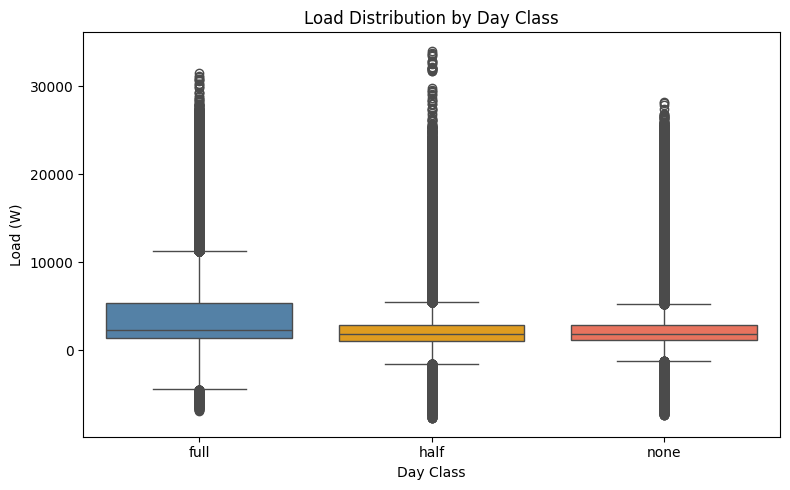


Load Stats By Class:


,count,mean,std,min,25%,50%,75%,max
day_class,,,,,,,,
full,90669.0,4372.72,5263.11,-6894.20,1423.88,2337.45,5350.23,31515.92
half,46058.0,2419.89,3656.85,-7742.17,1066.12,1810.54,2828.93,34057.93
none,53279.0,2988.07,4275.11,-7387.52,1195.92,1866.52,2831.40,28240.05


In [134]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='day_class', y='load', hue='day_class', palette=color_map,
            order=['full', 'half', 'none'], legend=False)
plt.title("Load Distribution by Day Class")
plt.xlabel("Day Class")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

print("\nLoad Stats By Class:")
display(df.groupby('day_class')['load'].describe().round(2))

### Load Distribution (monthly)

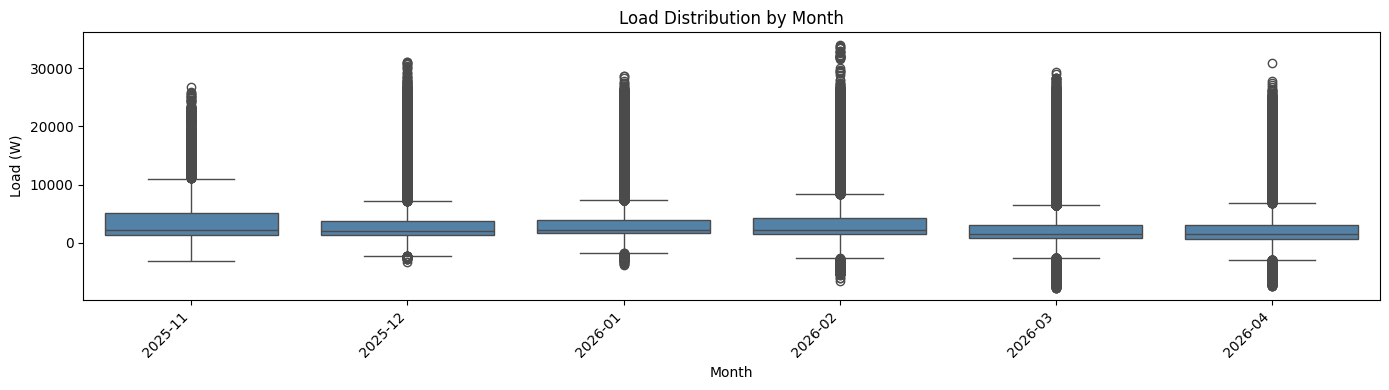

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
2025-11,4319.0,4539.46,5408.05,-3156.72,1281.70,2257.82,5187.62,26838.28
2025-12,44601.0,3584.11,4267.97,-3254.73,1345.05,2063.42,3705.00,31137.08
2026-01,44639.0,3815.12,4242.19,-3740.50,1633.62,2286.30,3915.40,28626.30
2026-02,40306.0,4023.51,4944.10,-6496.05,1480.21,2264.73,4256.33,34057.93
2026-03,44627.0,2765.74,4977.96,-7742.17,761.02,1560.60,3031.43,29257.95
2026-04,11514.0,2758.79,5545.13,-7387.52,702.09,1497.47,3139.00,30861.03


In [135]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x=df.index.to_period('M').astype(str), y='load', color='steelblue')
plt.title("Load Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Load (W)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(df.groupby(df.index.to_period('M'))['load'].describe().round(2))

### Load Distribution (daily)

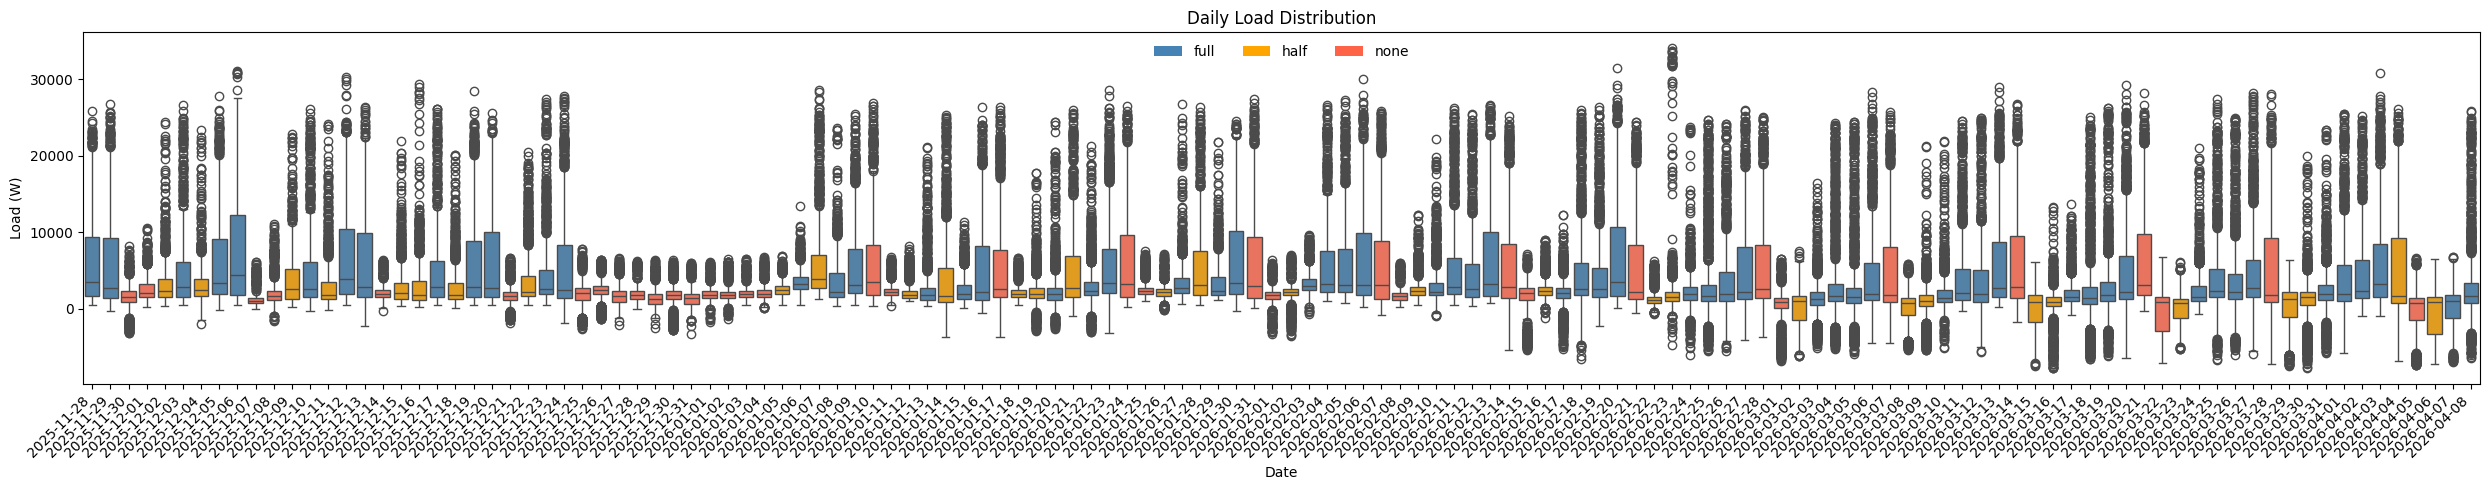

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
2025-11-28,1439.0,6200.92,5909.77,447.93,1684.22,3500.98,9455.06,25916.90
2025-11-29,1440.0,5748.48,6167.23,-308.64,1369.02,2774.97,9241.31,26838.28
2025-11-30,1440.0,1670.13,1537.39,-3156.72,947.40,1592.38,2395.70,8205.80
2025-12-01,1440.0,2579.47,1510.34,284.43,1548.58,2126.93,3261.06,10566.67
2025-12-02,1439.0,3313.73,3036.05,357.53,1576.91,2323.83,3886.12,24374.62
...,...,...,...,...,...,...,...,...
2026-04-04,1437.0,4883.72,6890.36,-6821.92,793.98,1646.00,9255.35,26110.82
2026-04-05,1440.0,-186.46,2617.58,-7387.52,-1487.85,813.23,1393.45,6684.62
2026-04-06,1440.0,-698.57,3104.82,-7154.53,-3283.65,893.19,1488.33,6553.20


In [136]:
plt.figure(figsize=(25, 5))
sns.boxplot(data=df, x=df.index.normalize(), y='load',
            hue=df['day_class'], palette=color_map, legend=False)
plt.title("Daily Load Distribution")
plt.xlabel("Date")
plt.ylabel("Load (W)")
plt.xticks(rotation=45, ha='right')

handles = [Patch(facecolor=color_map[cls], label=cls) for cls in color_map]
plt.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.tight_layout()
plt.show()

display(df.groupby(df.index.normalize())['load'].describe().round(2))

### Load Distribution (day of week)

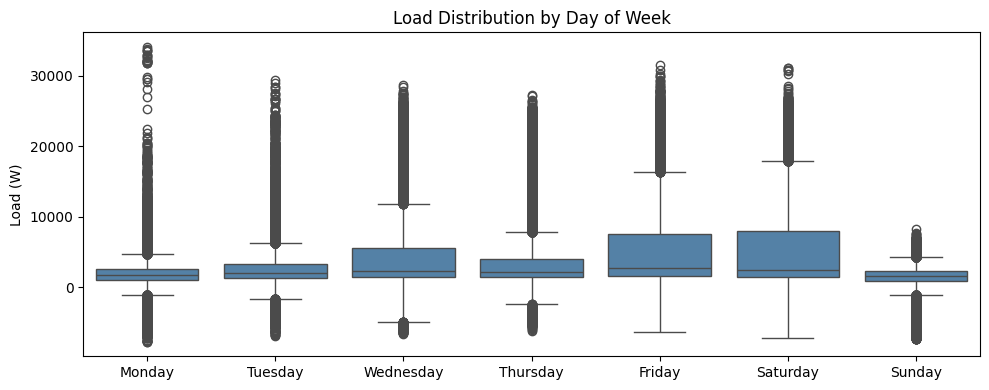

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
Monday,27344.0,1823.15,2574.78,-7742.17,1063.51,1768.60,2500.17,34057.93
Tuesday,27350.0,2689.61,2999.30,-6894.20,1288.05,2039.52,3255.11,29371.43
Wednesday,27331.0,4365.84,5403.12,-6644.41,1354.15,2309.05,5545.81,28626.30
Thursday,25918.0,3478.52,4206.85,-6210.00,1371.26,2124.78,3922.15,27290.02
Friday,27351.0,5523.30,5913.75,-6455.12,1621.23,2723.65,7519.20,31515.92
Saturday,27352.0,5412.24,6121.53,-7232.90,1368.23,2458.97,7960.20,31137.08
Sunday,27360.0,1284.03,2014.12,-7417.85,879.04,1575.97,2206.50,8205.80


In [137]:
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x=df.index.day_name(), y='load', order=days_order, color='steelblue')
plt.title("Load Distribution by Day of Week")
plt.xlabel("")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

display(df.groupby(df.index.day_name())['load'].describe().round(2).reindex(days_order))

### Load Distribution (hour)

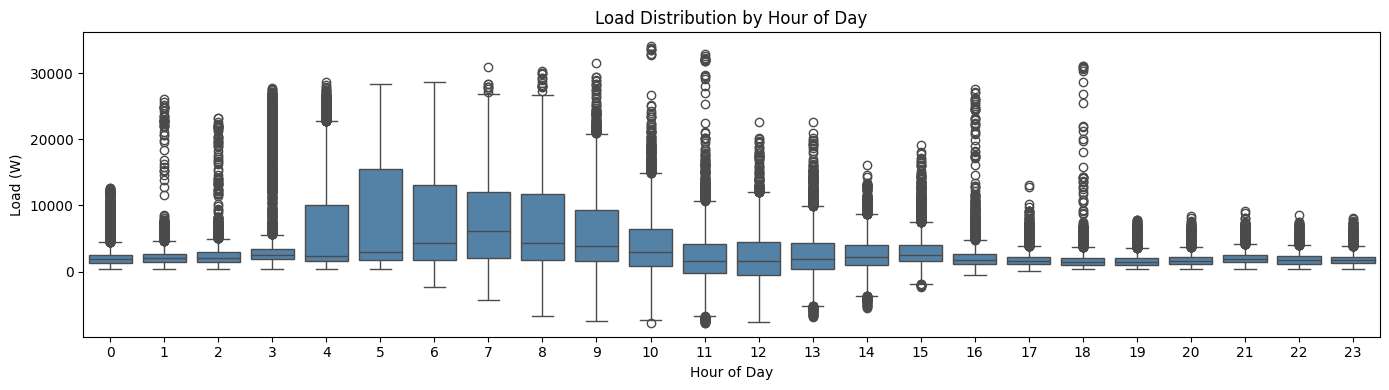

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,7920.0,2264.95,1687.11,402.60,1305.88,1843.79,2559.04,12588.13
1,7919.0,2368.10,1972.12,401.70,1386.30,1988.37,2707.35,26110.82
2,7919.0,2444.30,1802.01,397.63,1520.72,2130.68,2913.38,23202.29
3,7920.0,4430.74,5741.62,404.93,1877.03,2479.62,3374.63,27808.30
4,7919.0,6464.58,7394.09,404.53,1643.58,2347.87,10083.17,28626.30
5,7916.0,8432.86,7992.82,454.13,1815.48,2981.30,15513.10,28318.14
6,7920.0,7562.32,6666.38,-2334.33,1830.45,4324.76,13075.08,28613.97
7,7896.0,7268.36,6151.34,-4289.30,2076.17,6096.07,11981.96,30861.03
8,7915.0,6608.65,6752.03,-6699.83,1742.97,4299.65,11711.28,30258.63


In [138]:
plt.figure(figsize=(14, 4))
sns.boxplot(data=df, x=df.index.hour, y='load', color='steelblue')
plt.title("Load Distribution by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Load (W)")
plt.tight_layout()
plt.show()

display(df.groupby(df.index.hour)['load'].describe().round(2))

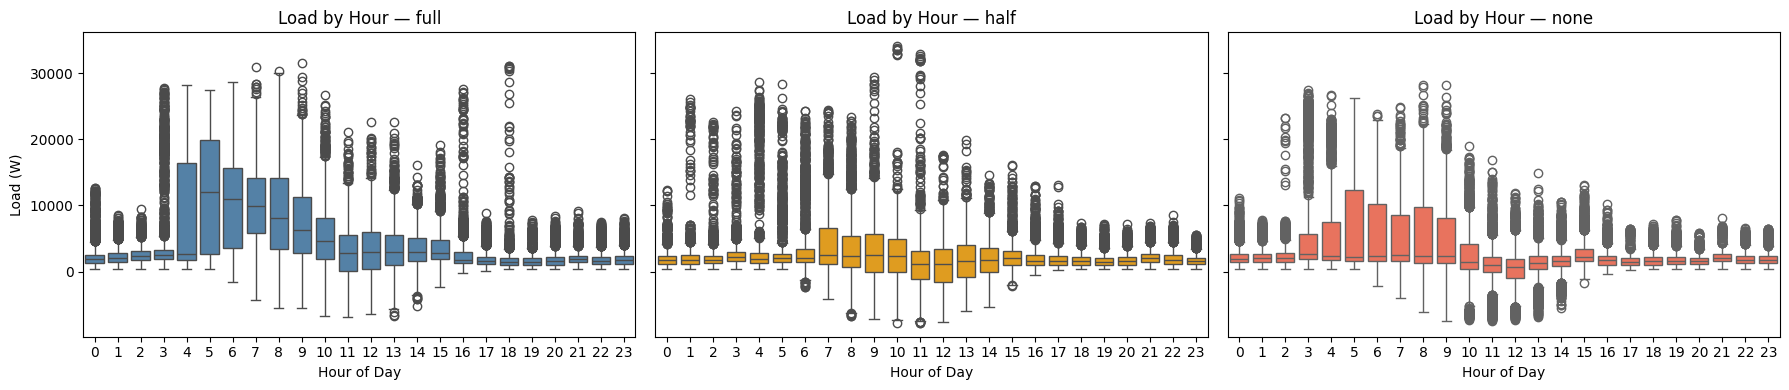


full:


,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,3780.0,2335.95,1827.14,405.67,1316.82,1885.65,2585.50,12588.13
1,3779.0,2389.10,1442.15,401.70,1478.38,2066.27,2829.42,8551.65
2,3780.0,2521.31,1160.64,397.63,1735.70,2352.09,3116.53,9480.60
3,3780.0,3800.70,4504.89,408.25,1955.79,2534.83,3339.40,27808.30
4,3780.0,8125.52,8189.52,425.08,1769.03,2683.82,16400.17,28236.73
5,3780.0,12157.96,8202.85,470.77,2662.99,12085.40,19909.56,27481.68
6,3780.0,10549.90,6557.65,-1615.30,3621.81,10923.42,15613.80,28613.97
7,3756.0,10101.74,5744.25,-4289.30,5816.39,9976.05,14112.96,30861.03
8,3775.0,8968.08,6667.77,-5516.45,3399.58,8117.93,14078.74,30258.63



half:


,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,1920.0,2047.61,1522.18,402.63,1137.82,1708.22,2351.60,12268.62
1,1920.0,2393.77,3127.78,402.63,1190.28,1727.89,2450.42,26110.82
2,1919.0,2316.12,2639.37,404.35,1247.00,1752.91,2409.52,22653.37
3,1920.0,2830.79,2561.47,404.93,1624.53,2215.62,2964.14,24249.29
4,1919.0,4244.17,6309.27,404.53,1342.83,1973.40,2828.26,28626.30
5,1917.0,3497.99,4371.05,454.13,1513.08,1999.63,2670.07,28318.14
6,1920.0,3913.00,4814.20,-2334.33,1434.49,2000.87,3429.37,24287.47
7,1920.0,4243.27,5186.57,-4208.17,1222.14,2444.94,6647.59,24374.62
8,1920.0,3461.23,5613.22,-6699.83,752.23,2389.02,5448.13,23376.40



none:


,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
0,2220.0,2332.02,1553.93,402.60,1388.22,1892.79,2653.61,11108.47
1,2220.0,2310.14,1368.16,403.10,1434.14,2023.89,2715.50,7873.72
2,2220.0,2423.99,1801.91,414.25,1491.03,2092.38,2816.86,23202.29
3,2220.0,6887.24,8275.50,434.83,1975.39,2588.23,5705.26,27438.20
4,2220.0,5555.87,6055.74,452.85,1699.38,2381.34,7472.68,26730.43
5,2219.0,6350.50,6913.33,461.27,1596.95,2236.20,12370.14,26240.38
6,2220.0,5631.52,5904.36,-2159.05,1622.88,2416.98,10179.81,23865.92
7,2220.0,5090.90,5410.81,-4021.72,1580.27,2476.22,8494.77,24905.65
8,2220.0,5318.64,6326.54,-6138.77,1379.02,2304.29,9784.82,28120.32


In [139]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, cls in zip(axes, ['full', 'half', 'none']):
    mask = df['day_class'] == cls
    sns.boxplot(data=df[mask], x=df[mask].index.hour, y='load',
                color=color_map[cls], ax=ax)
    ax.set_title(f"Load by Hour — {cls}")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Load (W)" if ax == axes[0] else "")

plt.tight_layout()
plt.show()

for cls in ['full', 'half', 'none']:
    mask = df['day_class'] == cls
    print(f"\n{cls}:")
    display(df[mask].groupby(df[mask].index.hour)['load'].describe().round(2))

## Clean Data

In [184]:
def clean_data(df):

  df = df.copy()

  # Resample to 1-second resolution
  df = df.resample('1min').agg({'load': 'mean', 'day_class': 'first'})

  # Remove missing load
  df = df.dropna(subset=['load'])

  return df

df_clean = clean_data(raw_df)
df_clean.head()

,load,day_class
timestamp,,
2025-11-28 00:00:00,1912.400000,full
2025-11-28 00:01:00,1908.233333,full
2025-11-28 00:02:00,1643.183333,full
2025-11-28 00:03:00,2992.950000,full
2025-11-28 00:04:00,1106.000000,full


## Feature Engineering

In [219]:
def create_features(df):
    df = df.copy()

    # Time features
    df['second']      = df.index.second
    df['minute']      = df.index.minute
    df['hour']        = df.index.hour
    df['dayofweek']   = df.index.dayofweek
    df['month']       = df.index.month
    df['year']        = df.index.year
    df['dayofyear']   = df.index.dayofyear
    df['weekend']     = (df['dayofweek'] > 4).astype(int)

    # Cyclical encoding
    df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']     = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']     = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)

    # Lag features (in seconds)
    df['lag_1min']    = df['load'].shift(60)
    df['lag_5min']    = df['load'].shift(300)
    df['lag_30min']   = df['load'].shift(1800)
    df['lag_1day']    = df['load'].shift(86400)
    df['lag_1week']   = df['load'].shift(604800)

    # Rolling features
    df['roll_mean_5min']  = df['load'].shift(1).rolling(300).mean()
    df['roll_std_5min']   = df['load'].shift(1).rolling(300).std()
    df['roll_mean_30min'] = df['load'].shift(1).rolling(1800).mean()
    df['roll_std_30min']  = df['load'].shift(1).rolling(1800).std()
    df['roll_max_30min']  = df['load'].shift(1).rolling(1800).max()
    df['roll_min_30min']  = df['load'].shift(1).rolling(1800).min()

    # One-hot encode
    df = pd.get_dummies(df, columns=['day_class'], prefix='day_class')

    return df


df_features = create_features(df_clean)
df_features.head()

,load,second,minute,hour,dayofweek,month,year,dayofyear,weekend,hour_sin,...,lag_1week,roll_mean_5min,roll_std_5min,roll_mean_30min,roll_std_30min,roll_max_30min,roll_min_30min,day_class_full,day_class_half,day_class_none
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-11-28 00:00:00,1912.400000,0,0,0,4,11,2025,332,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
2025-11-28 00:01:00,1908.233333,0,1,0,4,11,2025,332,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
2025-11-28 00:02:00,1643.183333,0,2,0,4,11,2025,332,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
2025-11-28 00:03:00,2992.950000,0,3,0,4,11,2025,332,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False
2025-11-28 00:04:00,1106.000000,0,4,0,4,11,2025,332,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,False,False


## Train/ Test Split

Use the final 20% of days as the test set, with the remainder used for training.

Train: 2025-11-28 → 2026-02-28 (93 days)
Val:   2026-02-28 → 2026-03-20 (21 days)
Test:  2026-03-20 → 2026-04-08 (20 days)


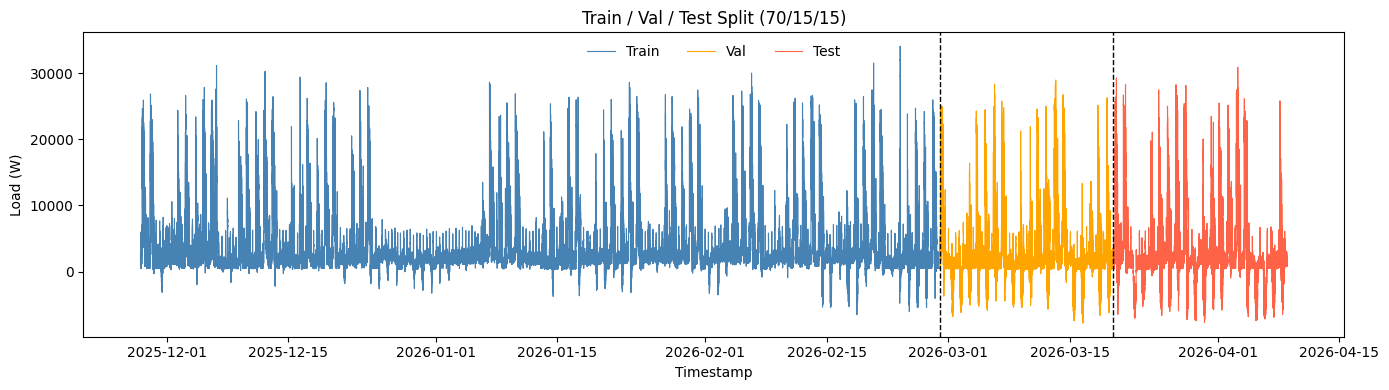

In [220]:
def train_val_test_split(df, val_size=0.15, test_size=0.15):
    """Train/Val/Test split by percent of days, chronologically"""
    n_days = df.index.normalize().nunique()
    n_test = int(np.ceil(n_days * test_size))
    n_val  = int(np.ceil(n_days * val_size))

    dates = df.index.normalize().unique().sort_values()
    val_date  = dates[-n_test - n_val]
    test_date = dates[-n_test]

    train = df.loc[:val_date]
    val   = df.loc[val_date:test_date]
    test  = df.loc[test_date:]
    return train, val, test

train, val, test = train_val_test_split(df_features)

print(f"Train: {train.index.min().date()} → {train.index.max().date()} ({train.index.normalize().nunique()} days)")
print(f"Val:   {val.index.min().date()} → {val.index.max().date()} ({val.index.normalize().nunique()} days)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()} ({test.index.normalize().nunique()} days)")

plt.figure(figsize=(14, 4))
plt.plot(train.resample('1min')['load'].mean(), color='steelblue', linewidth=0.8, label='Train')
plt.plot(val.resample('1min')['load'].mean(),   color='orange',    linewidth=0.8, label='Val')
plt.plot(test.resample('1min')['load'].mean(),  color='tomato',    linewidth=0.8, label='Test')
plt.axvline(train.index.max(), color='black', linestyle='--', linewidth=1)
plt.axvline(val.index.max(),   color='black', linestyle='--', linewidth=1)
plt.title("Train / Val / Test Split (70/15/15)")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncols=3, frameon=False)
plt.tight_layout()
plt.show()

Ensure all day classifications are being tested

In [221]:
train_raw, val_raw, test_raw = train_val_test_split(df)

for name, split in [('Train', train_raw), ('Val', val_raw), ('Test', test_raw)]:
    dist = split.groupby(split.index.normalize())['day_class'].first().value_counts()
    pct  = (dist / dist.sum() * 100).round(1)
    print(f"\n{name} Day Class Distribution:")
    print(pd.DataFrame({'days': dist, '%': pct}))


Train Day Class Distribution:
           days     %
day_class            
full         41  44.1
none         30  32.3
half         22  23.7

Val Day Class Distribution:
           days     %
day_class            
full         12  57.1
half          5  23.8
none          4  19.0

Test Day Class Distribution:
           days     %
day_class            
full         11  55.0
half          5  25.0
none          4  20.0


## Modeling

### XG Boost

Train

In [222]:
FEATURES = ['day_class_full', 'day_class_half', 'day_class_none', 'hour_sin', 'dow_sin', 'month_sin']
#FEATURES = [c for c in df_features.columns if c != 'load']
TARGET = 'load'

X_train = train[FEATURES]
X_val   = val[FEATURES]
X_test  = test[FEATURES]

y_train = train[TARGET]
y_val   = val[TARGET]
y_test  = test[TARGET]

reg = xgb.XGBRegressor(n_estimators=10000, early_stopping_rounds=50, learning_rate=0.01)
reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100
)

[0]	validation_0-rmse:4472.19453	validation_1-rmse:5045.86793
[100]	validation_0-rmse:3266.83577	validation_1-rmse:3800.77686
[200]	validation_0-rmse:3045.17264	validation_1-rmse:3548.05329
[300]	validation_0-rmse:2992.53750	validation_1-rmse:3468.48149
[400]	validation_0-rmse:2971.29769	validation_1-rmse:3428.71833
[500]	validation_0-rmse:2958.87400	validation_1-rmse:3403.80916
[600]	validation_0-rmse:2952.75924	validation_1-rmse:3392.79820
[700]	validation_0-rmse:2948.44469	validation_1-rmse:3389.28279
[800]	validation_0-rmse:2944.92134	validation_1-rmse:3387.42149
[900]	validation_0-rmse:2942.44215	validation_1-rmse:3386.71289
[1000]	validation_0-rmse:2938.84506	validation_1-rmse:3384.51141
[1100]	validation_0-rmse:2936.96932	validation_1-rmse:3383.78419
[1200]	validation_0-rmse:2935.46797	validation_1-rmse:3382.06123
[1254]	validation_0-rmse:2934.34348	validation_1-rmse:3382.34991


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10000,
             n_jobs=None, num_parallel_tree=None, ...)

Feature Importance

<Axes: title={'center': 'Feature Importance'}>

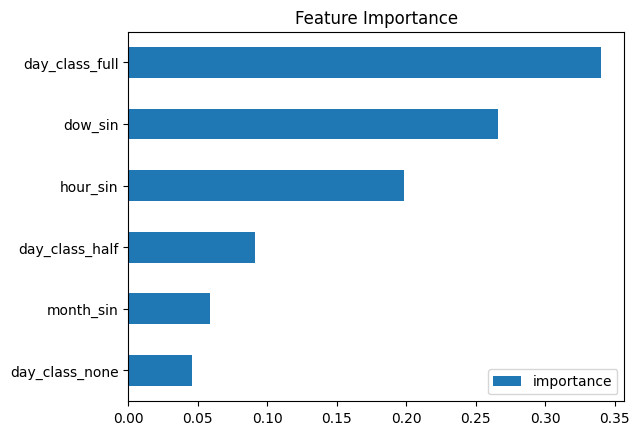

In [223]:
fi = pd.DataFrame(data=reg.feature_importances_, index = reg.feature_names_in_, columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')

Forecast

In [224]:
pred_val  = reg.predict(X_val)
pred_test = reg.predict(X_test)


XGBoost Evaluation:


,MAE,RMSE
Split,,
Val,2401.43,3381.95
Test,2627.13,3853.64


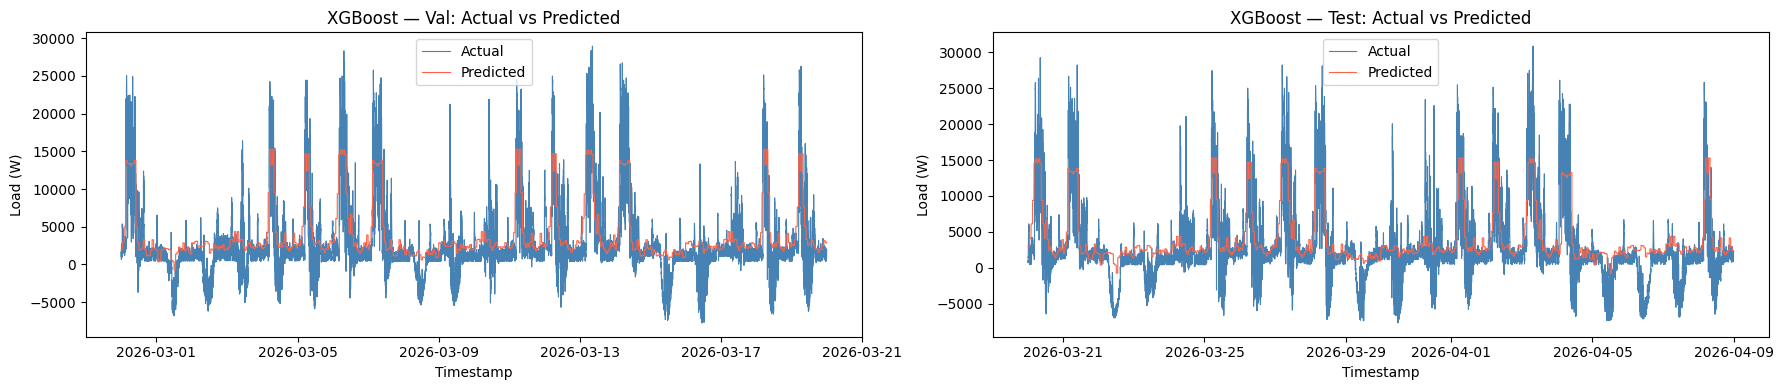

In [225]:
def evaluate_model(y_val, y_test, pred_val, pred_test, model_name='Model'):
    results = []
    for name, y_true, y_pred in [('Val', y_val, pred_val), ('Test', y_test, pred_test)]:
        mae  = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        results.append({'Split': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)})

    print(f"\n{model_name} Evaluation:")
    display(pd.DataFrame(results).set_index('Split'))

    fig, axes = plt.subplots(1, 2, figsize=(18, 4))
    for ax, (name, y_true, y_pred) in zip(axes, [('Val', y_val, pred_val), ('Test', y_test, pred_test)]):
        ax.plot(y_true.index, y_true.values, color='steelblue', linewidth=0.8, label='Actual')
        ax.plot(y_true.index, y_pred, color='tomato', linewidth=0.8, label='Predicted')
        ax.set_title(f"{model_name} — {name}: Actual vs Predicted")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Load (W)")
        ax.legend()
    plt.tight_layout()
    plt.show()

evaluate_model(y_val, y_test, pred_val, pred_test, model_name='XGBoost')